# RT-1

用 13 台机器人、17 个月采到的约 130k 条示范，训练一个 35M 参数的 Transformer 策略（FiLM 条件化的 EfficientNet + TokenLearner），，证明只要机器人数据足够多样，同一个模型就能泛化到新任务、新物体和新环境。

Transformer 的引入：

- 需要大容量模型 -> Transformer

- 控制器要实时执行 -> Transformer 的弱点（直接使用延迟大）

将输入输出（图像、文本等）编码成 "紧凑的 token"。

图片压缩，每个 token 小。

每帧只有很少的 token，序列长度小，Transformer 速度快。

## 网络设置

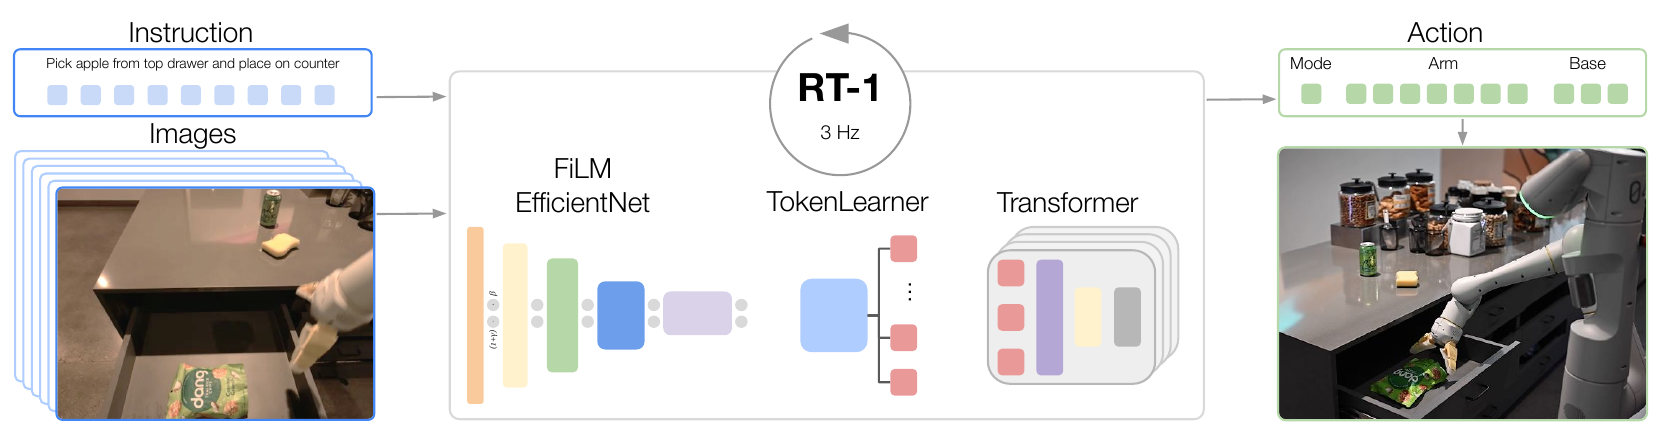

- FiLM EfficientNet

  指令先变成 USE 句向量，再经 FiLM 调制 ImageNet 预训练的 EfficientNet-B3。
  
  不是「图像编码完再和文字拼」——语言在卷积里就告诉视觉「看抽屉、看苹果」。每帧得到 9×9×512 特征图，展平为 81 个视觉-语言 token 。
- TokenLearner

  81 个 token 对 Transformer 太贵（注意力是 $O ( n^2 )$ ）。TokenLearner 做软选择，压到 每帧 8 个 token 。

  6 帧拼起来： 48 个 token 进 Transformer。这是 3 Hz 能跑起来的关键。
- Transformer

  decoder-only，8 层自注意力，约 19M 参数。把 48 个 token 映射成动作 token。

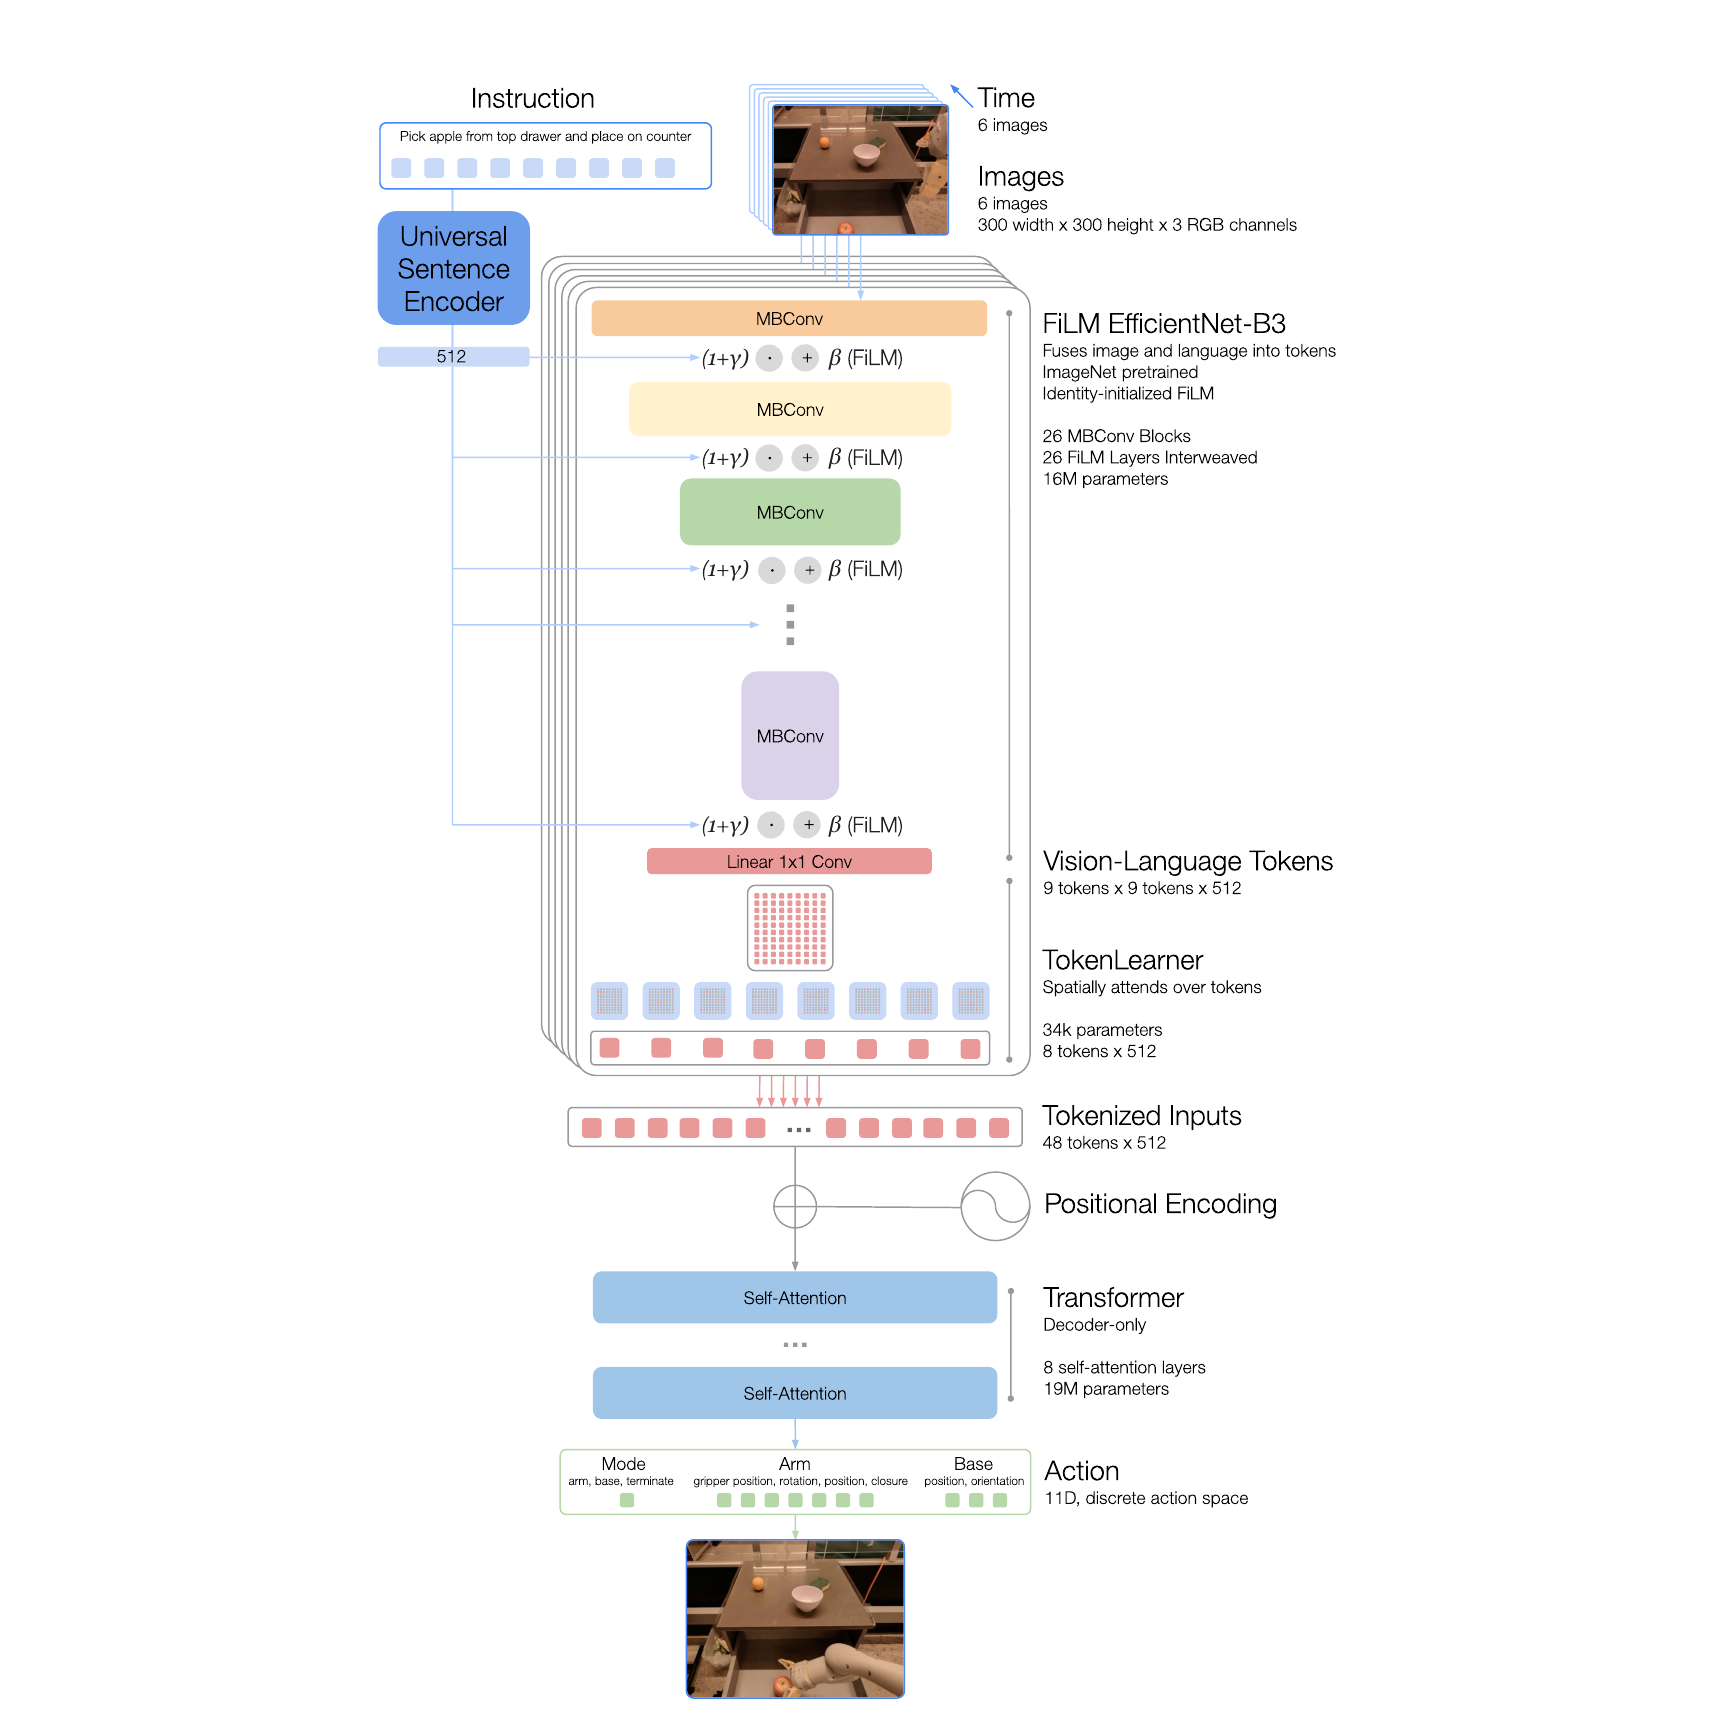

### FiLM EfficientNet

在 RT-1 中，FiLM 层对每个卷积特征图 **f**（形状如 9×9×512）施加语言条件：

$$
\gamma = \mathbf{W}_\gamma \mathbf{c} + \mathbf{b}_\gamma
$$

$$
\beta = \mathbf{W}_\beta \mathbf{c} + \mathbf{b}_\beta
$$

$$
f' = \gamma \odot f + \beta
$$

其中：

- **f**：EfficientNet 卷积层输出的特征图（逐通道独立调制）
- **c**：USE 句向量（512 维语言嵌入）
- **γ**：scale（尺度）参数，形状 = 通道数
- **β**：bias（偏移）参数，形状 = 通道数
- **⊙**：逐元素（element-wise）乘法
- **Wγ, bγ, Wβ, bβ**：可学习的线性投影层

“在卷积的同时”融入句向量：

1. **FiLM 层插在 EfficientNet 内部**EfficientNet-B3 由 26 层 MBConv 块组成。FiLM 层被**插入多个 MBConv 块之间**，而不是只在最后才和文本融合。
2. **条件化过程**句向量 **c** 先通过 FiLM 层生成两个向量（γ 和 β），这两个向量**与当前特征图 f 同时作用**：

   - 尺度 γ 控制“显著性”：哪些特征该放大（比如“看抽屉”时放大抽屉区域）
   - 偏移 β 控制“偏移”：把特征往语言相关的方向移动

   因此，当 EfficientNet 还在做卷积特征提取时，语言信息就已经“实时”地调制了特征。
3. **初始化方式（恒等初始化）**为了不破坏 EfficientNet 预训练的权重，作者把 FiLM 层的权重初始化为：

   - **γ = 1**（尺度恒等）
   - **β = 0**（偏移恒等）

   这相当于 FiLM 层一开始是“恒等变换”（f' = f），不会干扰卷积过程。等真正训练时，γ 和 β 才开始学怎么根据句向量去调制特征。

为什么这样设计？

- **早期融合**：语言在卷积的每一层都提前介入，而不是后面再把图像特征和文本特征拼接。
- **参数少**：FiLM 只需要两个投影矩阵（γ 和 β），几乎不增加计算量，却能显著提升任务相关性（论文中这是提升 RT-1 泛化的关键之一）。

一句话总结：
FiLM 就是把句向量 **c** 投影成两个参数 **γ** 和 **β**，然后在 EfficientNet 每一层卷积特征图 **f** 上同时做 **γ ⊙ f + β**，实现“语言在卷积过程中实时调制特征”的效果。

<a id="S021"></a>

### TokenLearner

学一个“软选择器” ，它会自动给 81 个 token 打分，再加权求和成 8 个 token，只保留最重要的那些。

**如何评估“重要”**：TokenLearner 学习一组 小数量的 key tokens，这些 key 就是模型自己“发现”的重要概念。待评价 token 与这些 key tokens 做相似度计算（点积等）。

## 实验设置

Everyday Robots 的移动操作机器人，它有一条 7 自由度机械臂、一个两指夹爪和一个移动底盘。

三个厨房场景：两个真实的办公室厨房，以及一个以这些真实厨房为原型搭建的训练环境。

## 结论

### 引入仿真数据可以提高模型的泛化能力

吸收仿真数据可以提升在"仅在仿真中出现过的物体"上的真实世界性能

### RT-1 模型在跨机器人平台上的泛化能力强

多机数据可以混合训练。

### 数据多样性比数据数量更关键

# RT-2

VLA 的提出：为了让自然语言回答与机器人动作适配到同一种格式，我们把动作表示为文本 token，并以与自然语言 token 完全相同的方式把它们直接纳入模型的训练集。我们把这一类模型称为视觉-语言-动作模型（VLA）。

目的是利用那些已经接触过远比机器人所见数据更为广泛的数据的 VLM 模型，在不增加新参数的情况下训练出 VLA 模型。

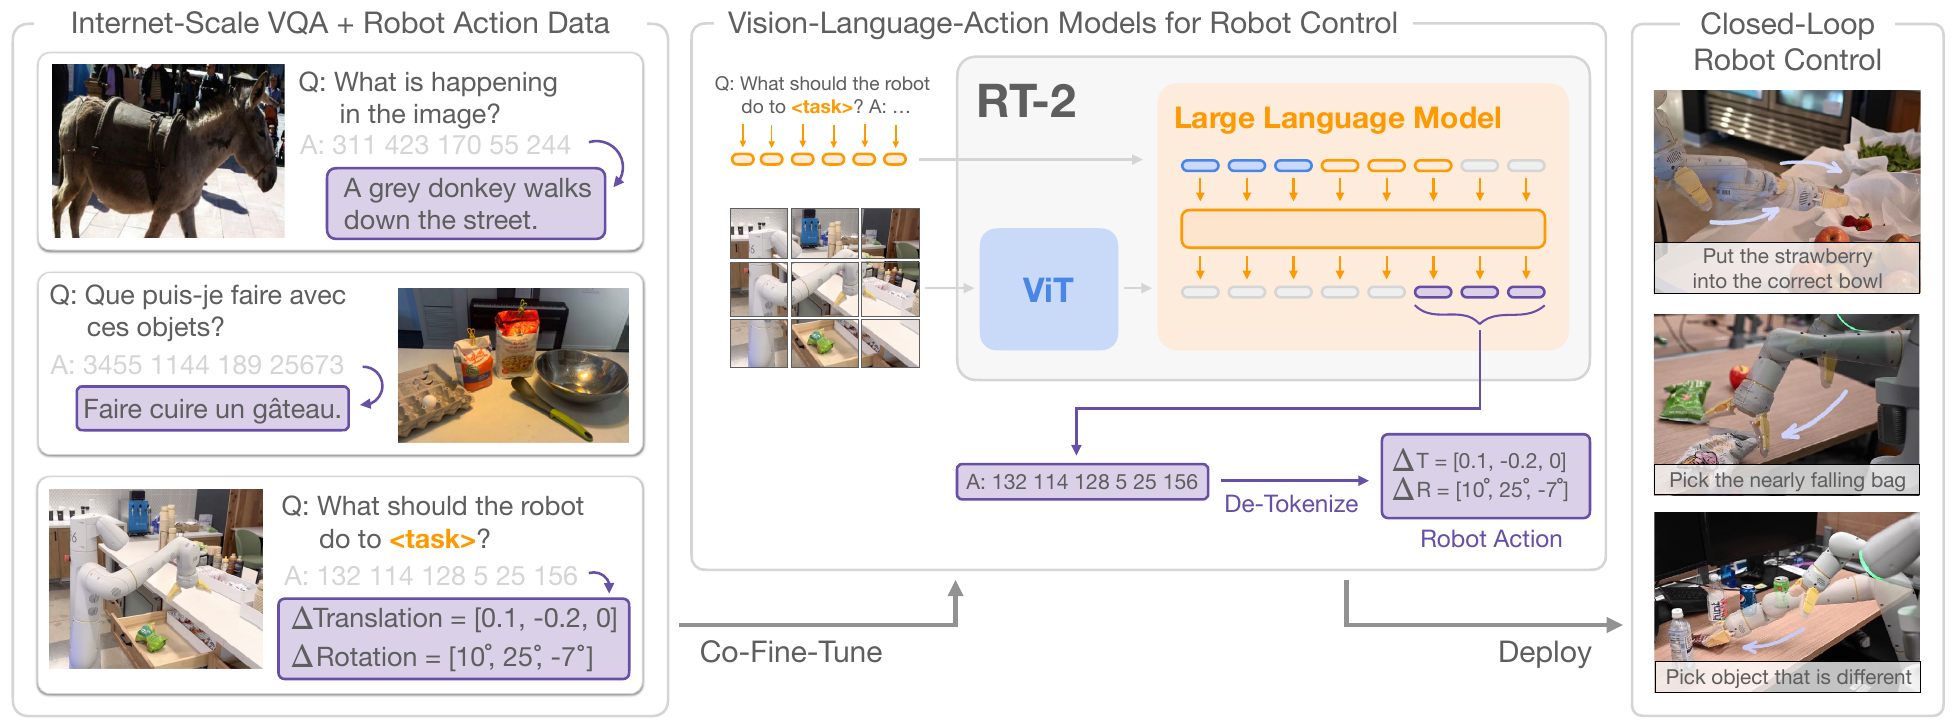

## VLA 具体的空间表示：

- 图像：映射进文字的嵌入空间：图像变成连续的 token 嵌入，和文本 token 嵌入一起被同一个 Transformer 处理。

- 动作：它是被"生成"的，不是被"编码"的：把离散动作 bin 直接关联到**词表里已有的 token**，只在输出位置

    - 动作空间由机器人末端执行器的 6 自由度位置与旋转位移、机器人夹爪的伸展程度，以及一个用于终止回合的特殊离散命令组成（共 8 位）

空间示意图：
```text
输入侧：  图像 ─ ViT ─ 投影层 ─┐
                              ├─→ Transformer 联合处理 ─→ 共享输出词表 ─→ 文本回答
          文本指令 ─ 分词 ────┘                                    └────→ 动作 token 串 ─→ 反离散化 ─→ ΔT / ΔR
```

为什么选择 { 视觉, 文本 } → { 文本 } 的视觉语言模型，而非 CLIP 这类表征学习模型，或设计一个{视觉、文本、动作}统一的嵌入空间？

1. 为什么不是 CLIP：CLIP 类模型没有"输出词表"：表征学习的目标函数是"区分"——把匹配的图文拉近、不匹配的推远。凡是**对区分没帮助**的语义内容，都会被这个瓶颈挤掉。故动作无法被放入嵌入空间。
2. 增加动作空间会增加参数（动作编码器、动作解码器）
3. 要训练一个"视觉-语言-动作共享空间"，就得用动作数据去塑造它的几何结构——而机器人动作恰恰是最稀缺的模态：网络侧有 10B 量级的图文对（S062），机器人侧只有 13 台机器人 17 个月的示范。**让丰富模态去迁就匮乏模态**，等于把瓶颈焊死在自己最缺的东西上。RT-2 的方向是反过来的：让动作迁就语言。

## 实验设置

云端部署：

把 RT-2 模型部署在多 TPU 云服务中并通过网络查询该服务，从而在机器人上运行这些模型

## 结论

### 评估 泛化 & 涌现

机器人数据里**有**这项技能（抓取、放置），只是物体、背景、词变了 → 泛化（知识来自机器人数据）

机器人数据里**根本没有**这个概念（数字、logo、人名、外语） → 涌现（知识来自互联网规模的视觉-语言预训练）

### 泛化能力强

在 VLM 微调时同时使用原始 VLM 训练数据与机器人数据，提升在未见数据上的泛化能力。

### 思维链

Plan and solve：

“Plan”步骤：先用自然语言描述机器人即将执行的动作的目的，随后再给出实际的动作 token，例如“Instruction: I'm hungry. Plan: pick rxbar chocolate. Action: 1 128 124 136 121 158 111 255.”

带有思维链推理的 RT-2 能够回答更复杂的指令，原因是它被给予了先以自然语言规划其动作的空间。

### 局限

- 模型的物理技能仍受限于机器人数据中出现的技能分布：需要研究如何通过新的数据采集范式（例如人类视频）来获得新技能

- 实时推理可能成为主要瓶颈

# RT-1 & RT-2

- RT-1：证明机器人数据的多样性能带来泛化（35M 参数、3 Hz 实时，纯机器人数据）。

- RT-2：把 RT-1 的动作协议搬进预训练 VLM，让网络知识直接进入低层控制。

|                   | RT-1                                | RT-2                       |
| ----------------- | ----------------------------------- | -------------------------- |
| 动作 token 的归属 | 策略私有的动作编码                  | VLM 词表中现成的词         |
| 训练对象          | 训练一个策略（35M）                 | 联合微调一个 VLM（5B–55B） |
| 语义知识来源      | 机器人数据 + 指令编码器             | 网络规模预训练             |
| 随什么变强        | 机器人数据的量与多样性              | VLM 骨干的规模             |
| 预训练知识的形态  | 分片：ImageNet（视觉）+ USE（语言） | 整体：一个多模态 VLM       |

RT-1 → RT-2 的三个增量

1. 知识来源：从"机器人数据 + 单模态预训练组件"变成"网络规模多模态预训练"。
2. 知识入口：从输入端（编码器）移到输出端（统一词表）——这是两篇论文之间唯一真正的结构性变化。
3. 进步路径：从"采更多样的机器人数据"变成"跟随 VLM 的进展"。